<div dir="rtl" style="font-size:22px; margin-left:-30px; margin-right:-30px">
<div dir="ltr" style="font-size:22px; margin-left:-30px; margin-right:-30px; text-align:center;">

# Graph Mining Presentation
# 📊 Graph Data Augmentation & Sampling Techniques
Armin Khojavi


</div>


## ❓ چرا این روش‌ها مهم هستند؟

- گراف‌ها ساختارهایی پیچیده، بزرگ و ناهمگنی (درجه های متفاوت) دارند.
- داده‌های برچسب‌دار در گراف‌ها محدود است.
- آموزش کامل مدل‌های گرافی (محاسبه کامل همسایگی برای هر گره غیرممکن است) ، پرهزینه و زمان‌بر است.

<br>

**🔴 Graph Data Augmentation:** ساختن نسخه‌های جدید و معنی‌دار از گراف اصلی با تغییر‌های کنترل‌شده (مثل حذف یا افزودن یال/گره، دستکاری ویژگی‌ها، یا استخراج زیرگراف) تا مدل بازنمایی‌های مقاوم‌تر و تعمیم‌پذیرتری یاد بگیرد

**🟢 Sampling Techniques:** انتخاب زیرمجموعه‌ای از گراف (گره‌ها، یال‌ها، یا زیرگراف‌ها) به‌جای پردازش کل گراف، برای کاهش هزینهٔ محاسباتی و حافظه و برای آموزش مدل‌ها روی گراف‌های خیلی بزرگ.

<br>

**Graph Data Augmentation موجب افزایش مقاومت مدل در برابر نویز می‌شود.**

**Sampling Techniques امکان آموزش مدل‌ها بر گراف‌های بزرگ را فراهم می‌سازد.**

</div>


<div dir="rtl" style="font-size:22px; margin-left:-30px;">

---
<div dir="ltr" style="font-size:22px; margin-left:-30px; margin-right:-30px; text-align:center;">

# 🟢 Graph Data Augmentation Methods
</br>

</div>

### 1️⃣ Node Dropping – حذف گره‌ها

<b>چطور کار می‌کند؟</b>  حذف بخشی از گره‌ها به‌صورت تصادفی یا هدفمند.

بخشی از گره‌های گراف به‌صورت تصادفی یا بر اساس معیارهای مشخصی (مانند درجه یا اهمیت) حذف می‌شوند. در نتیجه، تمام یال‌های متصل به این گره‌ها نیز از ساختار گراف حذف می‌گردند. 

هدف اصلی این روش، ایجاد نسخه‌ای ناقص اما معنادار از گراف است تا مدل در فرایند یادگیری، تنها به وابستگی‌های کامل ساختاری متکی نباشد.
روش شبیه به Dropout در شبکه‌های عصبی.

<b>مثال:</b>  
فرض کنید گراف شبکهٔ اجتماعی دارید و ۱۰٪ از کاربران را تصادفی حذف می‌کنید تا مدل یاد بگیرد حتی با داده‌های ناقص هم پیش‌بینی انجام دهد.

<b>✅ مزایا:</b>  
- فزایش مقاومت مدل (robustness) در برابر داده‌های ناقص یا حذف تصادفی گره‌ها
- کاهش overfitting از طریق ایجاد گراف‌های با ساختار متفاوت در طول آموزش
- تقویت تعمیم‌پذیری (generalization) در سناریوهای با گراف‌های ناقص یا پویا

<b>🔹 مناسب برای:</b>  
- Representation Learning  
- Contrastive Learning  

<b>⚠️ محدودیت‌ها:</b>  
- در گراف‌هایی با تعداد گره محدود یا زمانی که هر گره نقش حیاتی در معنا و تفسیر گراف دارد (مانند گراف‌های مولکولی)، این روش ممکن است منجر به از دست رفتن اطلاعات بحرانی شود.

</div>


In [22]:
# Single-run demo: apply 8 graph augmentation techniques separately and show BEFORE / AFTER visuals
# - All imports and dataset creation are done once at the top.
# - Each technique has a dedicated block that applies the transform and draws a side-by-side BEFORE/AFTER plot.
# - Comments are in English as requested. 
# - Visualization choices are simple and pedagogical (node color, edge width, timeline for temporal).

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
np.random.seed(0)
%matplotlib inline

# -------------------- Common setup (run once) --------------------
# Create a toy graph and node features (Zachary's Karate Club)
G0 = nx.karate_club_graph()      # 34 nodes, some community structure
num_nodes = G0.number_of_nodes()
# Node features: 6-d random vectors (can be anything: attributes or initial embeddings)
X0 = np.random.randn(num_nodes, 6).astype(float)

# Helper: fixed layout for consistent plotting
pos = nx.spring_layout(G0, seed=1)


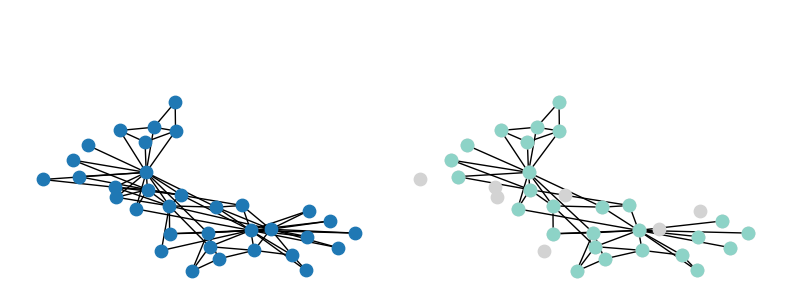

In [24]:
# -------------------- 1) Node Dropping ------------------------------------
def node_dropping(graph, features, drop_prob=0.12):
    """Randomly drop nodes with probability drop_prob.
       Returns new graph and feature matrix for remaining nodes."""
    G = graph.copy()
    to_remove = [n for n in G.nodes() if np.random.rand() < drop_prob]
    G.remove_nodes_from(to_remove)
    remaining = sorted(G.nodes())
    new_features = features[remaining]
    return G, new_features, to_remove

G_nd, X_nd, removed_nodes = node_dropping(G0, X0, drop_prob=0.12)

plt.figure(figsize=(8,3))
plt.suptitle("1) Node Dropping (before -> after)", fontsize=12)
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_size=80, with_labels=False)
plt.title("Original ({} nodes)".format(G0.number_of_nodes()))
plt.subplot(1,2,2)
# highlight removed nodes as faded locations: draw original nodes in light gray; draw remaining in blue
nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
nx.draw(G_nd, pos=pos, node_color='C0', node_size=80, with_labels=False)
plt.title("After node dropping (removed {})".format(len(removed_nodes)))
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


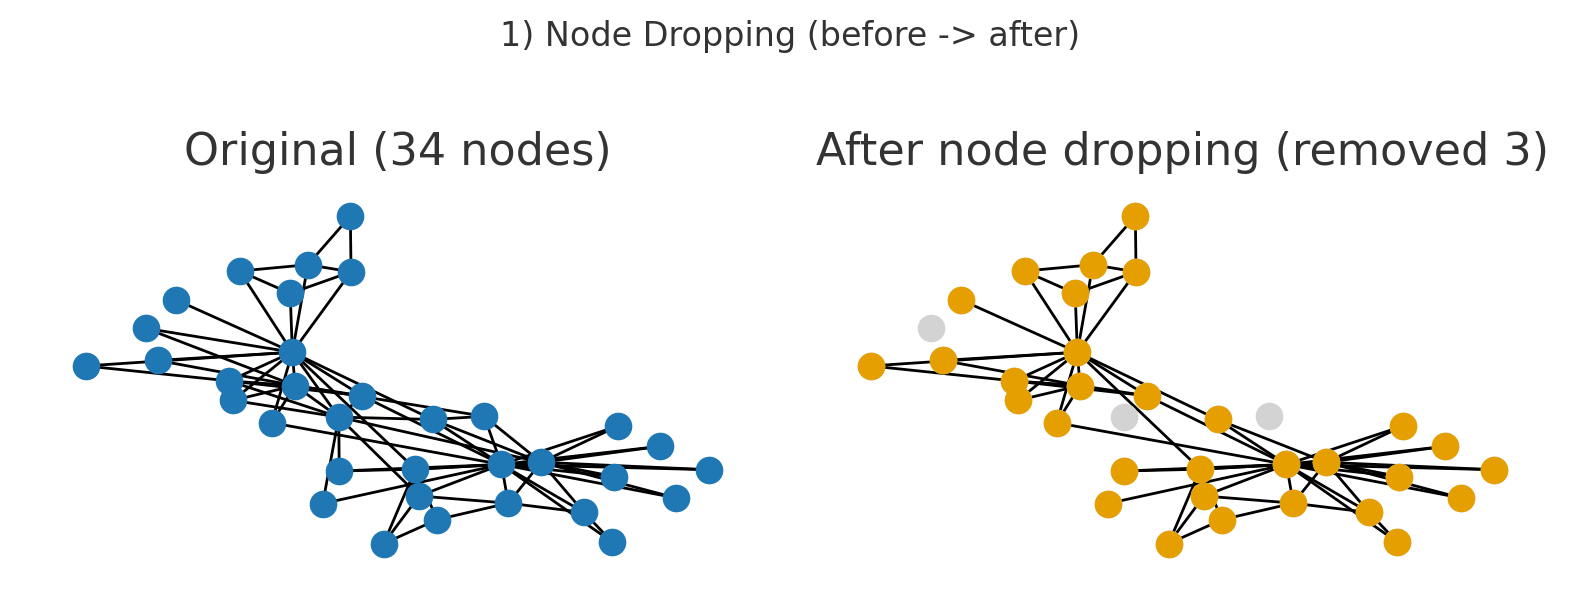

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 2️⃣ Edge Dropping / Perturbation – حذف یا تغییر یال‌ها

<b>چطور کار می‌کند؟  حذف یا بازاتصال تصادفی یال‌ها برای تولید نماهای متفاوت. </b>

در این روش، مجموعه‌ای از یال‌های گراف به‌صورت تصادفی یا مبتنی بر معیارهایی نظیر وزن، centrality یا اهمیت حذف، اضافه یا بازاتصال داده می‌شوند.
هدف اصلی، آموزش مدلی است که نسبت به تغییرات جزئی در ساختار گراف غیرحساس (structure-invariant) باشد.

<b>مثال:</b>  
در شبکهٔ نقل و انتقال مالی، حذف چند ارتباط ضعیف بین حساب‌ها برای افزایش پایداری مدل در مقابل noise در داده‌ها.

<b>✅ مزایا</b>  
- بهبود پایداری مدل در برابر نویز در داده‌های ساختاری.
- تولید نماهای متفاوت از یک گراف برای روش‌های contrastive learning مانند GraphCL.
- جلوگیری از یادگیری بیش از حد روی الگوهای خاص در ساختار اصلی گراف.

<b>🔹 مناسب برای:</b>  
- Graph Contrastive Learning  
- یادگیری تعمیم‌پذیر در گراف‌های پویا

<b>⚠️ محدودیت‌ها:</b>  
- در گراف‌هایی با معنا و وابستگی دقیق میان یال‌ها (نظیر شبکه‌های زیستی یا شیمیایی)، حذف یا تغییر یال ممکن است موجب از بین رفتن معنا یا روابط حیاتی شود.
- زمانی که حذف یال باعث disconnect شدن شدید گراف می‌شود.

</div>


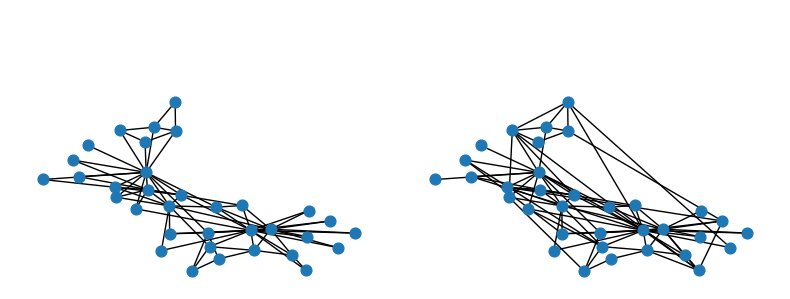

In [27]:
# -------------------- 2) Edge Dropping / Perturbation --------------------
def edge_perturbation(graph, drop_prob=0.15, add_prob=0.03):
    """Drop edges with drop_prob and add random non-edges with add_prob."""
    G = graph.copy()
    for u,v in list(G.edges()):
        if np.random.rand() < drop_prob:
            G.remove_edge(u,v)
    non_edges = list(nx.non_edges(G))
    for u,v in non_edges:
        if np.random.rand() < add_prob:
            G.add_edge(u,v)
    return G

G_ep = edge_perturbation(G0, drop_prob=0.15, add_prob=0.03)

plt.figure(figsize=(8,3))
plt.suptitle("2) Edge Perturbation (before -> after)", fontsize=12)
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_size=60, with_labels=False)
plt.title("Original edges: {}".format(G0.number_of_edges()))
plt.subplot(1,2,2)
nx.draw(G_ep, pos=pos, node_size=60, with_labels=False)
plt.title("After perturbation edges: {}".format(G_ep.number_of_edges()))
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


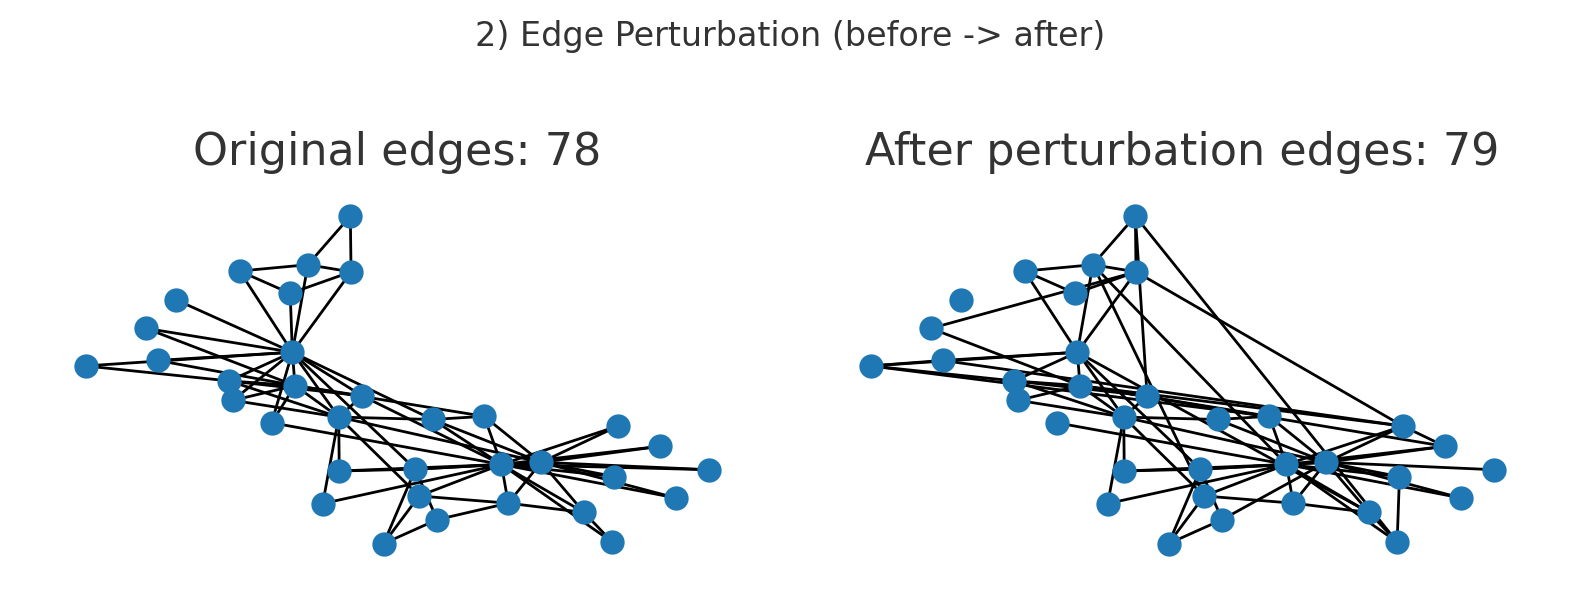

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 3️⃣ Feature Masking / Noise – ماسک یا نویز روی ویژگی‌ها

<b>چطور کار می‌کند؟ حذف یا افزودن نویز به ویژگی‌های گره‌ها یا یال‌ها.</b>  

🔹 بخشی از ویژگی‌های گره‌ها یا یال‌ها به‌صورت تصادفی ماسک (صفر یا حذف) می‌شوند یا نویز گوسی یا یکنواخت به آن‌ها افزوده می‌گردد. 

🔹 هدف از این فرایند، آموزش مدلی است که بتواند اطلاعات ناقص یا نویزی را با استفاده از ساختار گراف بازیابی یا جبران کند.

<b>🔹 مثال:</b>  
در گراف کاربر–محصول، برخی ویژگی‌ها مثل سن یا دسته‌بندی کالا را حذف یا با نویز تصادفی جایگزین می‌کنیم.

<b>✅ مزایا</b>  
- افزایش استحکام مدل در برابر داده‌های ناقص یا دارای نویز.
- وادار کردن مدل به استفادهٔ مؤثر از ساختار گراف به جای تکیهٔ صرف بر ویژگی‌ها.
- جلوگیری از overfitting و افزایش تعمیم‌پذیری.

<b>🔹 مناسب برای:</b>  
- داده‌های ناقص یا نویزی  

<b>⚠️ محدودیت‌ها:</b>  
- گراف‌هایی بدون ساختار قوی (مدل فقط به ویژگی‌ها وابسته است)
- ·در مواردی که ویژگی‌ها اطلاعات حیاتی و یکتا دارند (مانند ویژگی‌های فیزیکی یا شیمیایی دقیق)، افزودن نویز می‌تواند عملکرد مدل را کاهش دهد.

</div>


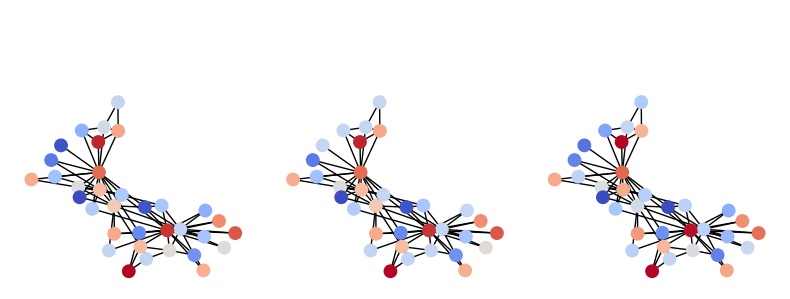

In [29]:
# -------------------- 3) Feature Masking / Noise --------------------------
def feature_masking(features, mask_prob=0.2):
    """Element-wise mask: zero out features with probability mask_prob."""
    mask = (np.random.rand(*features.shape) >= mask_prob)
    return features * mask

def feature_noise(features, noise_std=0.2):
    """Add Gaussian noise to features."""
    return features + np.random.randn(*features.shape) * noise_std

X_mask = feature_masking(X0, mask_prob=0.2)
X_noise = feature_noise(X0, noise_std=0.2)

# Visualize node color by first feature dimension before and after masking
vmin = X0[:,0].min(); vmax = X0[:,0].max()
plt.figure(figsize=(8,3))
plt.suptitle("3) Feature Masking / Noise (node color = feature dim0)", fontsize=12)
plt.subplot(1,3,1)
nx.draw(G0, pos=pos, node_color=X0[:,0], cmap='coolwarm', vmin=vmin, vmax=vmax, node_size=80, with_labels=False)
plt.title("Original feature dim0")
plt.subplot(1,3,2)
# masked values may have zeros -> show effect
nx.draw(G0, pos=pos, node_color=X_mask[:,0], cmap='coolwarm', vmin=vmin, vmax=vmax, node_size=80, with_labels=False)
plt.title("After masking (dim0)")
plt.subplot(1,3,3)
nx.draw(G0, pos=pos, node_color=X_noise[:,0], cmap='coolwarm', vmin=vmin, vmax=vmax, node_size=80, with_labels=False)
plt.title("After Gaussian noise (dim0)")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


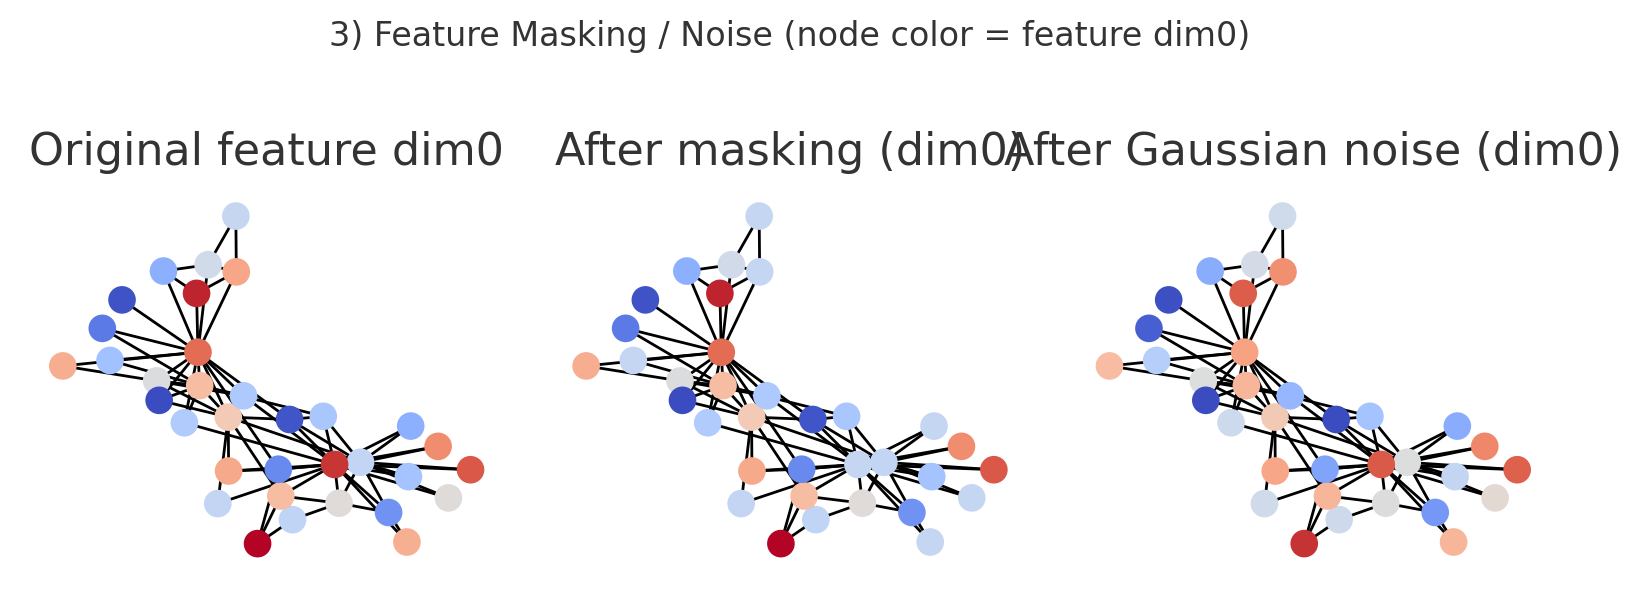

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 4️⃣ Subgraph Sampling / Cropping – نمونه‌گیری زیرگراف

**چطور کار می‌کند؟ استخراج زیرگراف‌های تصادفی از گراف اصلی.**  

🔹 به‌جای استفاده از کل گراف، یک زیرگراف استخراج می‌شود که می‌تواند به‌صورت تصادفی یا حول یک گره مرکزی انتخاب گردد. این زیرگراف‌ها می‌توانند به‌صورت node-induced (بر اساس انتخاب گره‌ها) یا edge-induced (بر اساس انتخاب یال‌ها) ساخته شوند.

🔹 هدف: کاهش پیچیدگی محاسباتی و تنوع در دادهٔ آموزشی.

**🔹 مثال:**  
در شبکهٔ اجتماعی بزرگ، فقط گراف محلی اطراف یک کاربر را برای آموزش انتخاب می‌کنیم.

**✅ مزایا:**  
- مناسب برای گراف‌های بزرگ‌مقیاس که پردازش کل آن‌ها دشوار است.
- ساخت نماهای محلی برای روش‌های contrastive learning.
- بررسی رفتار محلی در شبکه‌های پیچیده (مثلاً اطراف یک نود خاص).

**🔹 مناسب برای:**  
- گراف‌های بزرگ (مثلاً citation networks، social graphs)  
- Contrastive یا unsupervised learning

**⚠️ محدودیت‌ها:**  
- گراف‌های کوچک که حذف گره باعث از بین رفتن معنا می‌شود
- در گراف‌های کوچک یا زمانی که تحلیل روابط سراسری (global context) اهمیت دارد، نمونه‌گیری زیرگراف ممکن است منجر به از دست دادن اطلاعات کلی شود.

</div>


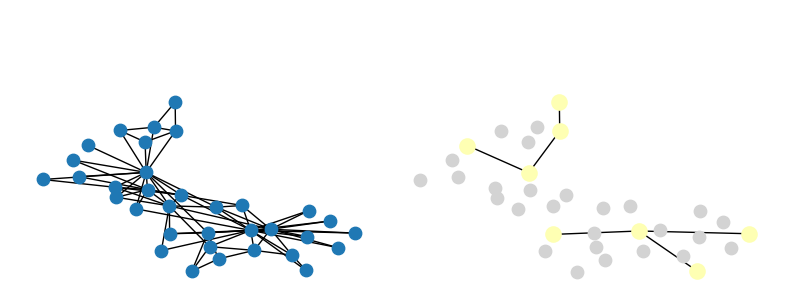

In [30]:
# -------------------- 4) Subgraph Sampling / Cropping ---------------------
def subgraph_node_induced(graph, features, k=8):
    """Randomly sample k nodes and return induced subgraph and corresponding features."""
    nodes = list(graph.nodes())
    k = min(k, len(nodes))
    chosen = np.random.choice(nodes, size=k, replace=False)
    subG = graph.subgraph(chosen).copy()
    node_list = sorted(subG.nodes())
    sub_feats = features[node_list]
    return subG, sub_feats, node_list

subG, subX, node_list = subgraph_node_induced(G0, X0, k=8)

plt.figure(figsize=(8,3))
plt.suptitle("4) Subgraph Sampling (node-induced) (before -> subgraph)", fontsize=12)
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_size=80, with_labels=False)
plt.title("Original full graph")
plt.subplot(1,2,2)
# draw only nodes in subgraph highlighted
nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
nx.draw(subG, pos=pos, node_color='C1', node_size=120, with_labels=False)
plt.title("Sampled subgraph nodes: {}".format(len(node_list)))
plt.tight_layout(rect=[0,0,1,0.95])
plt.plot()
plt.show(block=True)


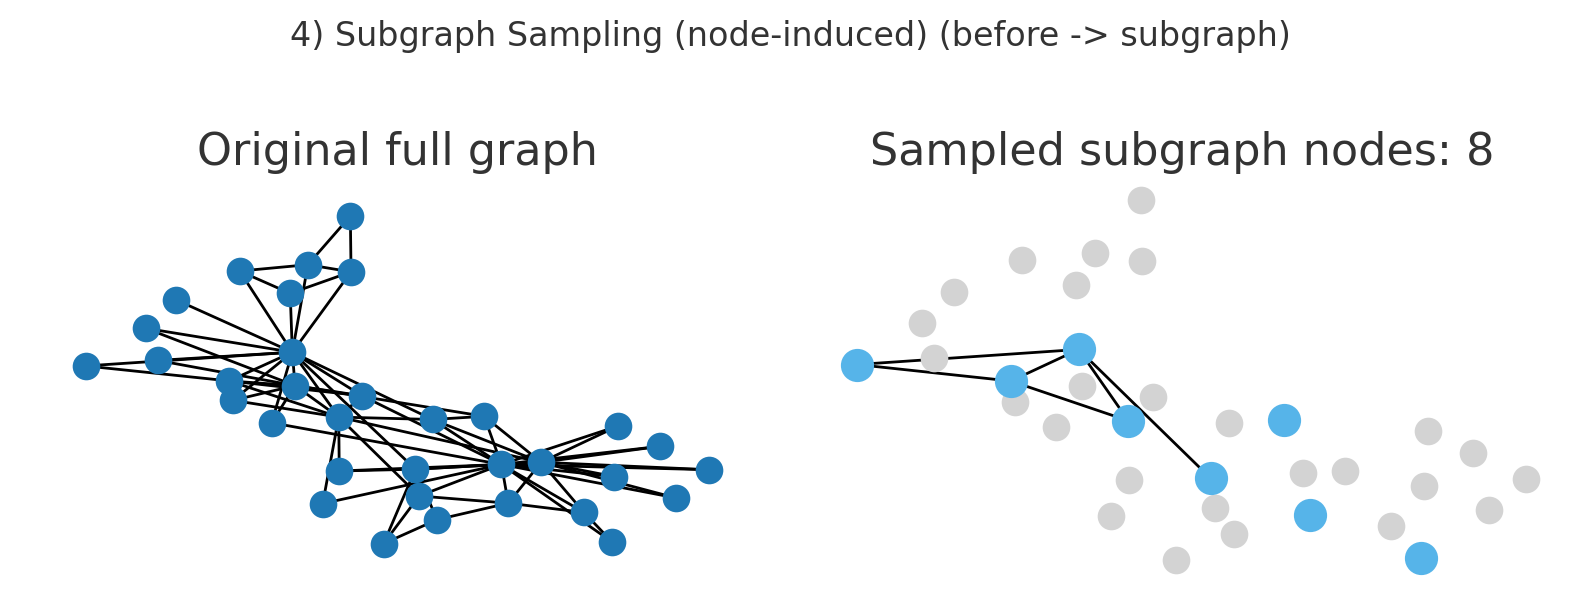

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 5️⃣ Attribute / Structure Mixup – ترکیب ویژگی یا ساختار

**چطور کار می‌کند؟ ترکیب ویژگی‌ها یا ساختار دو گراف با ضرایب مشخص.**  

🔹 این روش از Mixup در یادگیری عمیق اقتباس شده است و دو نوع دارد:  
1. Attribute Mixup: میانگین‌گیری وزنی ویژگی‌های گره‌های دو گراف یا زیرگراف.  
2. Structure Mixup: ترکیب ماتریس مجاورت (Adjacency Matrix) دو گراف با ضرایب خاص.

**🔹 هدف:**  افزایش تنوع داده و جلوگیری از overfitting از طریق ایجاد داده‌های مصنوعی میان‌گرافی.

**🔹 مثال:**  در گراف‌های مولکولی، دو مولکول ترکیب‌شده را به‌صورت میانگین وزنی از adjacency و feature می‌سازیم.

**✅ مزایا:**  
- تقویت regularization در مدل‌های graph-level. (منظم‌سازی): یعنی روش‌هایی برای جلوگیری از overfitting — وقتی مدل فقط داده‌های آموزشی را "حفظ" می‌کند و در دادهٔ جدید ضعیف می‌شود.
- ایجاد داده‌های ترکیبی برای بهبود generalization (تعمیم‌پذیری):توانایی مدل در عملکرد خوب روی داده‌هایی که در آموزش ندیده است.
- مفید برای graph classification یا graph contrastive learning.

**🔹 مزیت:** تقویت تعمیم‌پذیری مدل.


**⚠️ محدودیت‌ها:**  
- در مواردی که ترکیب دو گراف از نظر معنا بی‌ارتباط یا غیرمنطقی است، این روش ممکن است داده‌های نامعتبر ایجاد کند (مثلاً ترکیب دو شبکهٔ اجتماعی غیرمرتبط).
- گراف‌های زمانی یا پویا که ساختار ترکیبی منطقی ندارد

</div>


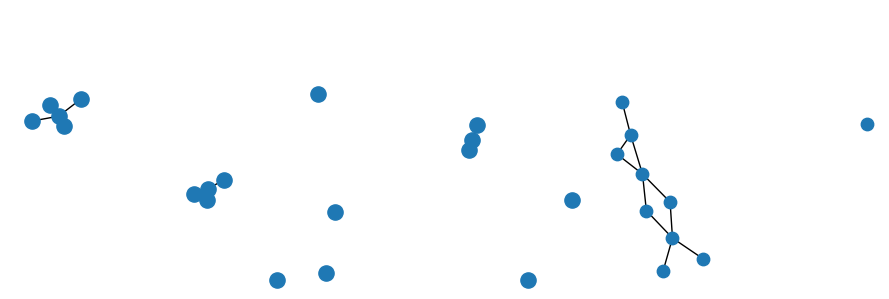

In [32]:
# -------------------- 5) Attribute / Structure Mixup ----------------------
def simple_graph_mixup(Ga, Xa, Gb, Xb, alpha=0.3):
    """Mix two small graphs heuristically at adjacency and feature level."""
    A1 = nx.to_numpy_array(Ga, nodelist=sorted(Ga.nodes()))
    A2 = nx.to_numpy_array(Gb, nodelist=sorted(Gb.nodes()))
    n = max(A1.shape[0], A2.shape[0])
    def pad(A, n):
        B = np.zeros((n,n))
        B[:A.shape[0], :A.shape[1]] = A
        return B
    A1p, A2p = pad(A1,n), pad(A2,n)
    X1p = np.zeros((n, Xa.shape[1])); X1p[:Xa.shape[0],:] = Xa
    X2p = np.zeros((n, Xb.shape[1])); X2p[:Xb.shape[0],:] = Xb
    lam = np.random.beta(alpha, alpha) if alpha>0 else 0.5
    A_mix = lam*A1p + (1-lam)*A2p
    thresh = A_mix.mean()
    A_bin = (A_mix >= thresh).astype(int)
    Gmix = nx.from_numpy_array(A_bin)
    Xmix = lam*X1p + (1-lam)*X2p
    return Gmix, Xmix, lam

# pick two random small subgraphs to mix
G_a, X_a, _ = subgraph_node_induced(G0, X0, k=10)
G_b, X_b, _ = subgraph_node_induced(G0, X0, k=8)
G_mix, X_mix, lam = simple_graph_mixup(G_a, X_a, G_b, X_b, alpha=0.3)

plt.figure(figsize=(9,3))
plt.suptitle("5) Attribute/Structure Mixup (two subgraphs -> mixed)", fontsize=12)
plt.subplot(1,3,1)
nx.draw(G_a, node_size=120, with_labels=False)
plt.title("Graph A (n={})".format(G_a.number_of_nodes()))
plt.subplot(1,3,2)
nx.draw(G_b, node_size=120, with_labels=False)
plt.title("Graph B (n={})".format(G_b.number_of_nodes()))
plt.subplot(1,3,3)
nx.draw(G_mix, node_size=80, with_labels=False)
plt.title("Mixed (lambda={:.2f}, n={})".format(lam, G_mix.number_of_nodes()))
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


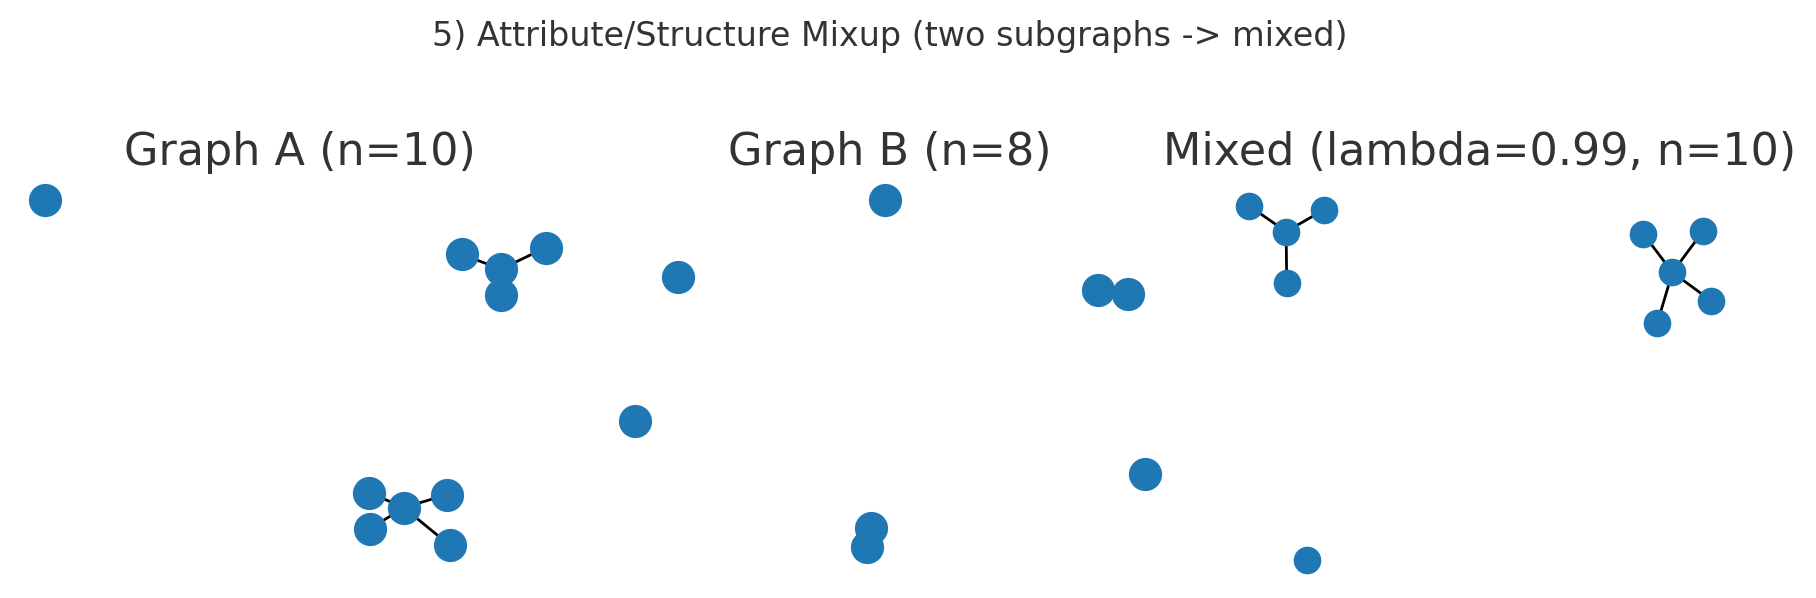

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 6️⃣ Edge Reweighting / Sparsification – تغییر وزن‌ یا تنک‌سازی یال‌ها

**چطور کار می‌کند؟ نظیم وزن یال‌ها بر اساس معیارهایی چون مرکزیت یا شباهت.**  

🔹 در این روش، وزن یال‌ها با توجه به معیارهایی مانند centrality، betweenness، یا similarity تنظیم می‌شوند. در حالت خاص‌تر، می‌توان یال‌هایی با اهمیت پایین را حذف (sparsify) کرد. 

**🔹 هدف:**  تمرکز مدل بر روی روابط کلیدی‌تر و حذف اتصالات کم‌اهمیت است.

**🔹 مثال:**  در گراف ترافیکی، مسیرهایی که عبور کمتر دارند وزن کمتر گرفته یا حذف می‌شوند.

**✅ مزایا:**  
- کاهش پیچیدگی ساختاری گراف‌های بسیار متصل.
- حذف نویز از گراف‌های متراکم.
- تأکید بر مسیرها و ارتباطات بحرانی.
- بهبود کارایی محاسبات
- ساده سازی گراف

**⚠️ محدودیت‌ها:**  
- در گراف‌هایی که اطلاعات وزن یال مشخص نیست یا اهمیت هر اتصال دقیقاً قابل اندازه‌گیری نیست، این روش ممکن است ساختار را به‌صورت نادرست ساده کند. همچنین در گراف‌های کوچک، حذف حتی یک یال می‌تواند ساختار را به‌شدت تغییر دهد.
- در گراف‌های کوچک، حذف حتی یک یال می‌تواند تغییر زیادی ایجاد کند

</div>


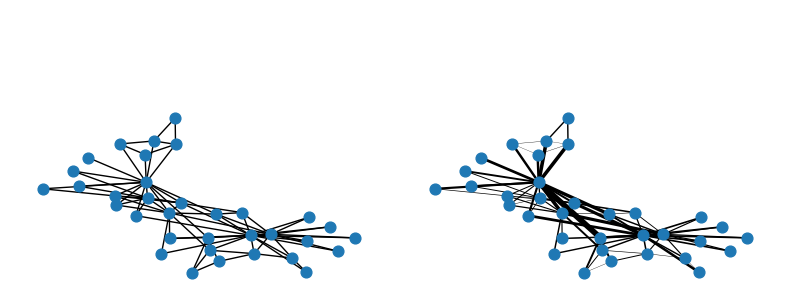

In [33]:
def edge_reweight_by_betweenness(graph):
    """Compute edge betweenness centrality and store normalized weight on edges."""
    G = graph.copy()
    eb = nx.edge_betweenness_centrality(G)
    if len(eb)==0:
        return G
    maxv = max(eb.values())
    for (u,v), val in eb.items():
        G[u][v]['weight'] = val / maxv if maxv>0 else 0.0
    return G

def sparsify_by_weight(graph, keep_ratio=0.5):
    """Remove edges with low 'weight' attribute until keep_ratio of edges remain."""
    G = graph.copy()
    edges = list(G.edges(data=True))
    if not edges:
        return G
    weights = np.array([edata.get('weight', (G.degree(u)*G.degree(v))) for u,v,edata in edges], dtype=float)
    thr = np.quantile(weights, 1-keep_ratio)
    for u,v,edata in edges:
        w = edata.get('weight', (G.degree(u)*G.degree(v)))
        if w < thr and G.has_edge(u,v):
            G.remove_edge(u,v)
    return G

G_rw = edge_reweight_by_betweenness(G0)
G_sp = sparsify_by_weight(G_rw, keep_ratio=0.5)

plt.figure(figsize=(8,3))
plt.suptitle("6) Edge Reweighting / Sparsification", fontsize=12)
plt.subplot(1,2,1)
# draw original with uniform thin edges
nx.draw(G0, pos=pos, node_size=60, with_labels=False)
plt.title("Original edges: {}".format(G0.number_of_edges()))
plt.subplot(1,2,2)
# draw sparsified graph with edge widths proportional to 'weight' (if present)
edges = G_rw.edges(data=True)
widths = [edata.get('weight', 0.1)*4 + 0.1 for u,v,edata in edges]
nx.draw(G_rw, pos=pos, node_size=60, width=widths, with_labels=False)
plt.title("Edge-weighted view (before sparsify)\nthen sparsified has {} edges".format(G_sp.number_of_edges()))
plt.tight_layout(rect=[0,0,1,0.95])
plt.show(block=True)


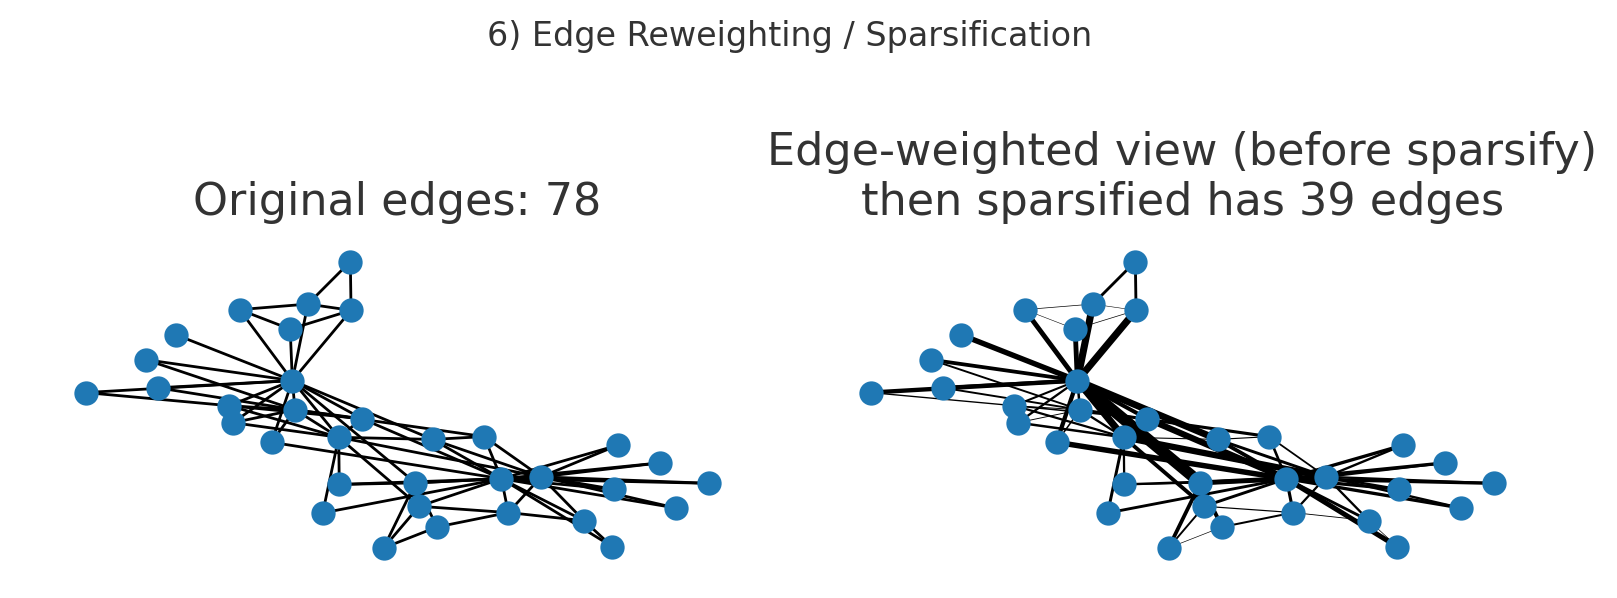

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 7️⃣ Graph Diffusion / Smoothing Aug – پراکندگی و هموارسازی

**چطور کار می‌کند؟ انتشار ویژگی‌ها با استفاده از فیلترهایی نظیر PPR یا Heat Kernel.**  

🔹 این روش بر پایهٔ ایدهٔ انتشار اطلاعات در سراسر گراف بنا شده است.
در آن، ویژگی‌های گره‌ها با استفاده از فیلترهای انتشار (diffusion filters) مانند Personalized PageRank (PPR)  یا Heat Kernel  در میان همسایگی‌هایشان پخش می‌شوند. این کار باعث ایجاد ویژگی‌های هموار و چندمقیاسی می‌شود که هم اطلاعات محلی و هم اطلاعات سراسری را دربر دارد.

‼ Personalized PageRank (PPR): از ایدهٔ گوگل سرچ آمده؛ احتمال این‌که از یک نود خاص شروع کنیم و از طریق یال‌ها در گراف حرکت کنیم.
نتیجه: وزن‌هایی که نشان می‌دهد هر گره چقدر به گرهٔ اولیه مرتبط است.

‼ Heat Kernel:مدل‌سازی انتشار تدریجی اطلاعات در زمان، شبیه به پخش گرما روی سطح.

**🔹 مثال:**  
در گراف استناد علمی، ویژگی هر مقاله (embedding) با توجه به مقالاتی که آن را cite کرده‌اند، هموار می‌شود.

**✅ مزایا:**  
- افزایش کیفیت بازنمایی‌های گره (node embeddings).
- ترکیب مناسب اطلاعات ساختاری و ویژگی‌های گره.
- تولید چندین نمای مختلف از گراف برای contrastive learning یا pretraining.

**🔹 مناسب برای:**  
- همه‌ی مدل‌های spectral یا message-passing  
- Pretraining و self-supervised learning

**⚠️ محدودیت‌ها:**  
- در گراف‌های بسیار متراکم، هموارسازی بیش از حد می‌تواند تفاوت‌های محلی میان گره‌ها را از بین ببرد. همچنین در گراف‌های زمانی، انتشار ممکن است ترتیب زمانی را مخدوش کند.
- گراف‌های زمانی (زیرا توالی زمانی را از بین می‌برد)

</div>


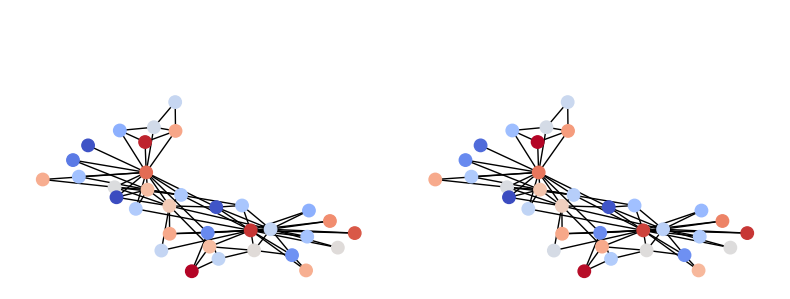

In [37]:
# -------------------- 7) Graph Diffusion / Smoothing (PPR) ----------------
def personalized_pagerank_feature_smoothing(graph, features, alpha=0.2):
    """Compute PPR-like smoothing and apply to features (dense solver)."""
    A = nx.to_numpy_array(graph, nodelist=sorted(graph.nodes()))
    deg = A.sum(axis=1)
    D_inv = np.diag([1/d if d>0 else 0.0 for d in deg])
    M = D_inv @ A
    n = A.shape[0]
    I = np.eye(n)
    try:
        mat = np.linalg.inv(I - alpha*M)
    except np.linalg.LinAlgError:
        mat = np.linalg.pinv(I - alpha*M)
    PPR = (1-alpha) * mat
    X_new = PPR @ features[sorted(graph.nodes())]
    return X_new

X_ppr = personalized_pagerank_feature_smoothing(G0, X0, alpha=0.25)

plt.figure(figsize=(8,3))
plt.suptitle("7) Graph Diffusion / Smoothing (PPR) - node color = feature dim0", fontsize=12)
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_color=X0[:,0], cmap='coolwarm', node_size=80, with_labels=False)
plt.title("Original feature dim0")
plt.subplot(1,2,2)
nx.draw(G0, pos=pos, node_color=X_ppr[:,0], cmap='coolwarm', node_size=80, with_labels=False)
plt.title("PPR-smoothed feature dim0")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show(block=True)


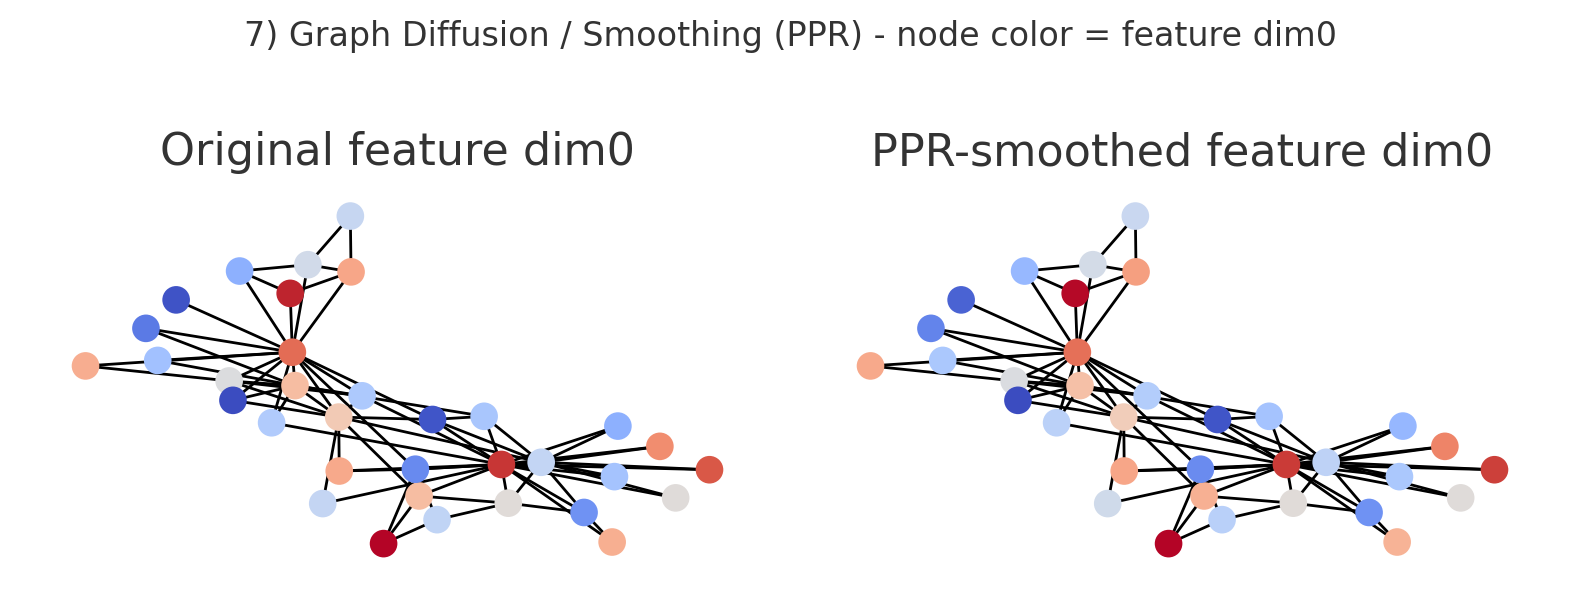

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 8️⃣ Temporal Augmentations – تغییرات زمانی در گراف‌های زمانی

**چطور کار می‌کند؟ ایجاد تغییرات کنترل‌شده در بُعد زمانی.**  

🔹 در گراف‌های زمانی یا پویا که یال‌ها و گره‌ها در طول زمان تغییر می‌کنند، این روش به تغییر جزئی در بُعد زمانی داده‌ها می‌پردازد. این تغییر می‌تواند شامل جابجایی timestamps، حذف یا اضافه‌کردن رویدادها، و یا بازآرایی توالی رویدادها باشد.

**🔹 هدف:** مقاوم‌سازی مدل در برابر نوسانات زمانی.

**🔹 مثال:**  
در گراف تراکنش‌ها، چند رویداد خرید را به‌صورت تصادفی در زمان جابه‌جا می‌کنیم تا مدل به توالی دقیق حساس نباشد.

**✅ مزایا:**  
- افزایش مقاومت در برابر خطای زمانی
- شبیه‌سازی داده‌های ناقص یا نویزی در سناریوهای زمانی احتمالی آینده (مانند تراکنش‌ها یا تعاملات کاربر).
- مقاوم‌سازی مدل‌های Temporal Graph Neural Networks (TGNNs).

**🔹 کابردها:**  
- گراف‌های زمانی یا event-based (تراکنش، تعامل کاربر، شبکه‌های ارتباطی)

**⚠️ محدودیت‌ها:**  
- گراف‌های ایستا
- در کاربردهایی که ترتیب زمانی نقش علّی و حیاتی دارد (مانند مدل‌سازی روابط علت و معلول یا رخدادهای پزشکی)، اعمال تغییرات زمانی می‌تواند منجر به از بین رفتن معنای واقعی داده‌ها شود.

</div>


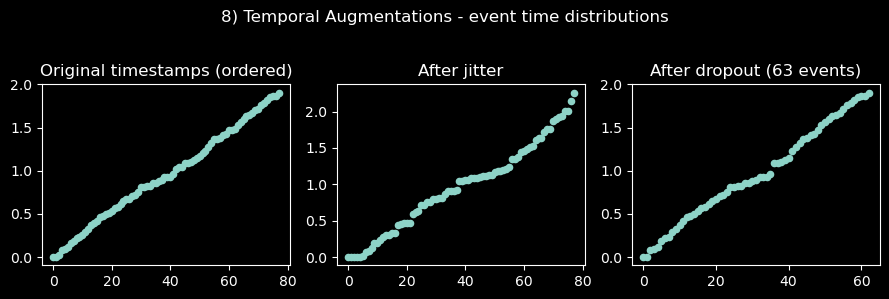

In [38]:
# -------------------- 8) Temporal Augmentations ---------------------------
# Create a synthetic list of events (u, v, t) by enumerating edges and assign increasing times
events = []
t = 0.0
for u,v in G0.edges():
    events.append((u,v,t))
    t += 0.05 * np.random.rand()

events_sorted = sorted(events, key=lambda x: x[2])

def temporal_jitter(events, jitter_std=0.3):
    """Add Gaussian jitter to event timestamps (clamped to >=0)."""
    out = []
    for u,v,t in events:
        t2 = max(0.0, t + np.random.randn()*jitter_std)
        out.append((u,v,t2))
    return sorted(out, key=lambda x: x[2])

def temporal_event_dropout(events, drop_prob=0.2):
    """Drop each event with probability drop_prob."""
    return [e for e in events if np.random.rand() >= drop_prob]

def temporal_reorder(events, swap_frac=0.1):
    """Swap timestamps between random event pairs for a fraction of events."""
    ev = list(events)
    m = len(ev)
    n_swaps = max(1, int(m * swap_frac))
    for _ in range(n_swaps):
        i,j = np.random.choice(m, size=2, replace=False)
        ti = ev[i][2]; tj = ev[j][2]
        ev[i] = (ev[i][0], ev[i][1], tj)
        ev[j] = (ev[j][0], ev[j][1], ti)
    return sorted(ev, key=lambda x: x[2])

events_jit = temporal_jitter(events_sorted, jitter_std=0.3)
events_drop = temporal_event_dropout(events_sorted, drop_prob=0.2)
events_reord = temporal_reorder(events_sorted, swap_frac=0.1)

# Visualize event timestamp distribution before and after jitter/drop
plt.figure(figsize=(9,3))
plt.suptitle("8) Temporal Augmentations - event time distributions", fontsize=12)
plt.subplot(1,3,1)
times = [e[2] for e in events_sorted]
plt.scatter(range(len(times)), times, s=20)
plt.title("Original timestamps (ordered)")
plt.subplot(1,3,2)
times_j = [e[2] for e in events_jit]
plt.scatter(range(len(times_j)), times_j, s=20)
plt.title("After jitter")
plt.subplot(1,3,3)
times_d = [e[2] for e in events_drop]
plt.scatter(range(len(times_d)), times_d, s=20)
plt.title("After dropout ({} events)".format(len(times_d)))
plt.tight_layout(rect=[0,0,1,0.95])
plt.show(block=True)


<div dir="rtl" style="display:flex; justify-content:center; margin-top:20px; margin-bottom:20px;">

<div style="font-size:22px; line-height:1.8; text-align:center;">

### 📘 خلاصه کلی روش‌های Augmentation

<table>
<thead>
<tr>
<th>نوع روش</th>
<th>محور تغییر</th>
<th>🎯 هدف اصلی</th>
<th>💡 کاربرد بهینه</th>
<th>⚠️ موارد نامناسب</th>
</tr>
</thead>
<tbody>
<tr>
<td>🧱 Node Dropping</td>
<td>ساختاری</td>
<td>افزایش مقاومت در برابر حذف داده</td>
<td>contrastive, semi-supervised</td>
<td>گراف‌های کوچک یا حساس</td>
</tr>
<tr>
<td>🔗 Edge Dropping</td>
<td>ساختاری</td>
<td>مقاومت در برابر تغییرات ساختاری</td>
<td>contrastive learning</td>
<td>شبکه‌های زیستی/شیمیایی</td>
</tr>
<tr>
<td>🎭 Feature Masking</td>
<td>ویژگی</td>
<td>regularization و تحمل نویز</td>
<td>همهٔ گراف‌ها</td>
<td>ویژگی‌های حیاتی و دقیق</td>
</tr>
<tr>
<td>🧩 Subgraph Sampling</td>
<td>ساختاری</td>
<td>کاهش هزینه و افزایش تنوع</td>
<td>گراف‌های بزرگ</td>
<td>گراف‌های کوچک یا global</td>
</tr>
<tr>
<td>🧬 Mixup</td>
<td>ساختاری / ویژگی</td>
<td>regularization بین‌نمونه‌ای</td>
<td>graph-level tasks</td>
<td>داده‌های نامرتبط</td>
</tr>
<tr>
<td>⚖️ Reweighting</td>
<td>ساختاری</td>
<td>حذف نویز، برجسته‌سازی مسیر</td>
<td>گراف‌های متراکم</td>
<td>داده‌های بدون معیار اهمیت</td>
</tr>
<tr>
<td>🌪 Diffusion</td>
<td>ویژگی</td>
<td>ترکیب دید محلی و جهانی</td>
<td>pretraining / self-supervised</td>
<td>گراف‌های بسیار dense</td>
</tr>
<tr>
<td>⏳ Temporal Aug</td>
<td>زمانی</td>
<td>مقاوم‌سازی در بعد زمان</td>
<td>TGNNs, event graphs</td>
<td>داده‌های علّی یا ایستا</td>
</tr>
</tbody>
</table>

</div>
</div>


<div dir="rtl" style="font-size:22px; margin-left:-30px;">

---
<div dir="ltr" style="font-size:22px; margin-left:-30px; margin-right:-30px; text-align:center;">

## 🟢 Sampling Techniques
</div>

### 1️⃣ Uniform Node Sampling – نمونه‌گیری یکنواخت گره‌ها

**چطور کار می‌کند؟ انتخاب تصادفی گره‌ها با احتمال یکسان.**  

🔹در این روش، تعدادی از گره‌های گراف به‌صورت تصادفی و یکنواخت انتخاب می‌شوند، بدون در نظر گرفتن ساختار یا ویژگی خاصی. در نتیجه، همه‌ی گره‌ها احتمال انتخاب یکسانی دارند. معمولاً زیرگراف القایی (node-induced subgraph) از همین گره‌ها استخراج می‌شود.

**🔹 مثال:**  فرض کنید در یک شبکه‌ی اجتماعی با ۱۰ میلیون کاربر، می‌خواهیم آماری از میانگین درجهٔ ارتباط کاربران به‌دست آوریم.به جای پردازش کل شبکه، می‌توانیم ۱٪ از گره‌ها را به‌صورت یکنواخت انتخاب و میانگین درجهٔ همان زیرمجموعه را محاسبه کنیم.

**✅ مزایا:**  
- ساده و سریع  
- مناسب برای تحلیل آماری اولیه

**🔹 مناسب برای:**  
- گراف‌های نسبتاً همگن یا بدون وزن
- تحلیل‌های آماری یا تخمین ویژگی‌های کلی شبکه

**⚠️ محدودیت‌ها:**  
- در گراف‌های ناهمگن، گره‌های با درجهٔ بالا یا اهمیت زیاد ممکن است کمتر نمونه شوند.
- ممکن است زیرگراف انتخابی، ساختار واقعی شبکه را به‌خوبی منعکس نکند.

</div>


In [40]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
np.random.seed(0)

# -------------------- Common setup --------------------
G0 = nx.karate_club_graph()
pos = nx.spring_layout(G0, seed=1)


In [70]:
# # 1) Uniform Node Sampling
# def uniform_node_sampling(G, k=8):
#     nodes = random.sample(list(G.nodes()), min(k, G.number_of_nodes()))
#     subG = G.subgraph(nodes).copy()
#     return subG, nodes

# G_uniform, nodes_uniform = uniform_node_sampling(G0, k=8)
# plt.figure(figsize=(8,3))
# plt.suptitle("1) Uniform Node Sampling")
# plt.subplot(1,2,1)
# nx.draw(G0, pos=pos, node_size=80, with_labels=False)
# plt.title("Original")
# plt.subplot(1,2,2)
# nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
# nx.draw(G_uniform, pos=pos, node_color='C0', node_size=120, with_labels=False)
# plt.title("Sampled nodes: {}".format(len(nodes_uniform)))
# plt.tight_layout()
# plt.show()


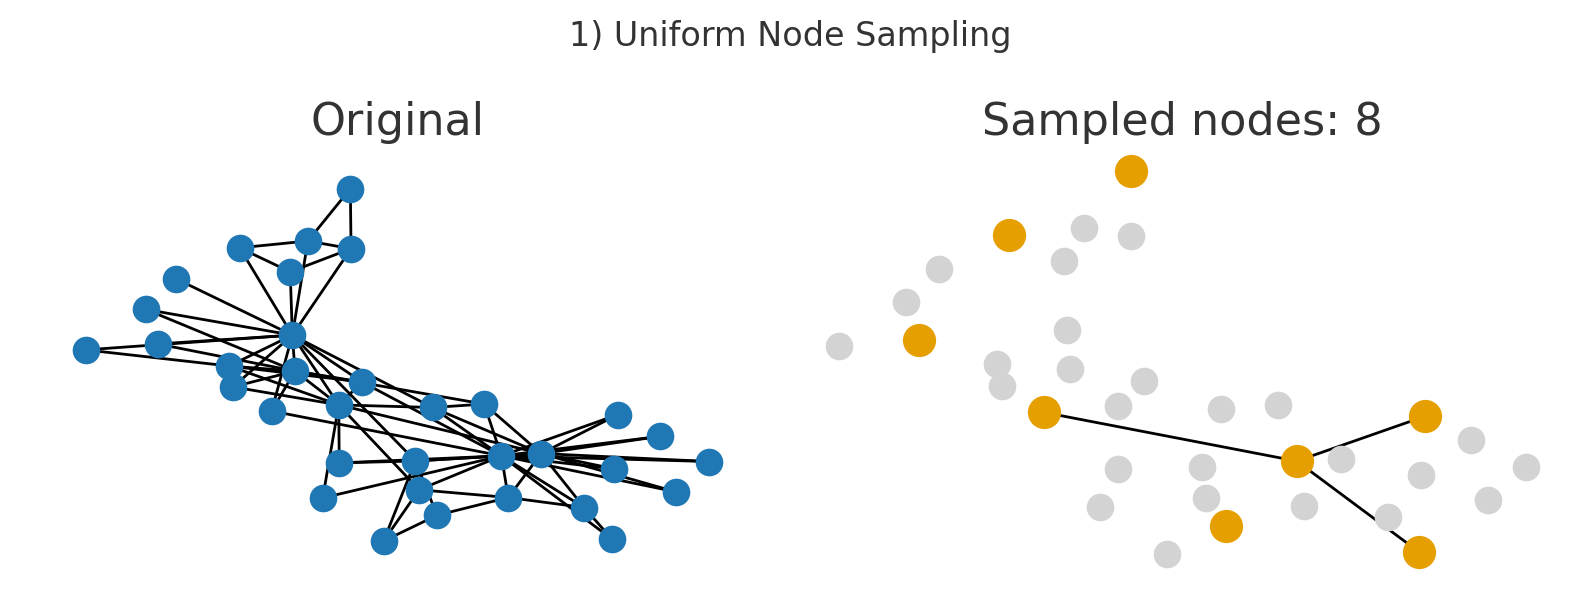

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 2️⃣ Neighbor (Neighborhood) Sampling – نمونه‌گیری همسایگی

**چطور کار می‌کند؟ تعدادی از همسایه‌های آن گره به صورت تصادفی یا با روش‌های خاص انتخاب می‌شوند.**  

🔹 در این روش، برای هر گره هدف، تعدادی از k همسایه‌ی تصادفی آن انتخاب می‌شوند.این فرآیند در هر لایه از GNN تکرار می‌شود. روش معروف GraphSAGE از این نمونه‌گیری برای محدودکردن تعداد گره‌های پردازش‌شده استفاده می‌کند.

**🔹 مثال:** در GraphSAGE، اگر گره A سه همسایه دارد (B, C, D) و ما k=2 تعیین کنیم، در هر forward pass فقط دو همسایه (مثلاً B و D) برای پیام‌رسانی انتخاب می‌شوند.

**✅ مزایا:**  
- کاهش چشمگیر هزینه محاسباتی در گراف‌های بزرگ  
- کنترل رشد نمایی تعداد گره‌های فعال در GNN  
- حفظ اطلاعات محلی

**⚠️ محدودیت‌ها:**  
- برخی همسایه‌های مهم ممکن است حذف شوند  
- نمونه‌گیری تصادفی ممکن است تنوع نمایشی را کاهش دهد

**🔹 مناسب برای:**  
- مدل‌های Node-level (مثل GraphSAGE، PinSAGE)  
- گراف‌های متراکم و بزرگ (شبکه اجتماعی، citation networks)

</div>


In [69]:
# # 2) Neighbor Sampling
# def neighbor_sampling(G, seed_node=0, k=4):
#     neighbors = list(G.neighbors(seed_node))
#     sampled = random.sample(neighbors, min(k, len(neighbors)))
#     subG = G.subgraph([seed_node]+sampled).copy()
#     return subG, sampled

# G_neigh, neigh_nodes = neighbor_sampling(G0, seed_node=0, k=4)
# plt.figure(figsize=(8,3))
# plt.suptitle("2) Neighbor Sampling (seed node=0)")
# plt.subplot(1,2,1)
# nx.draw(G0, pos=pos, node_size=80, with_labels=False)
# plt.title("Original")
# plt.subplot(1,2,2)
# nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
# nx.draw(G_neigh, pos=pos, node_color='C1', node_size=120, with_labels=False)
# plt.title("Neighbors sampled: {}".format(neigh_nodes))
# plt.tight_layout()
# plt.show()


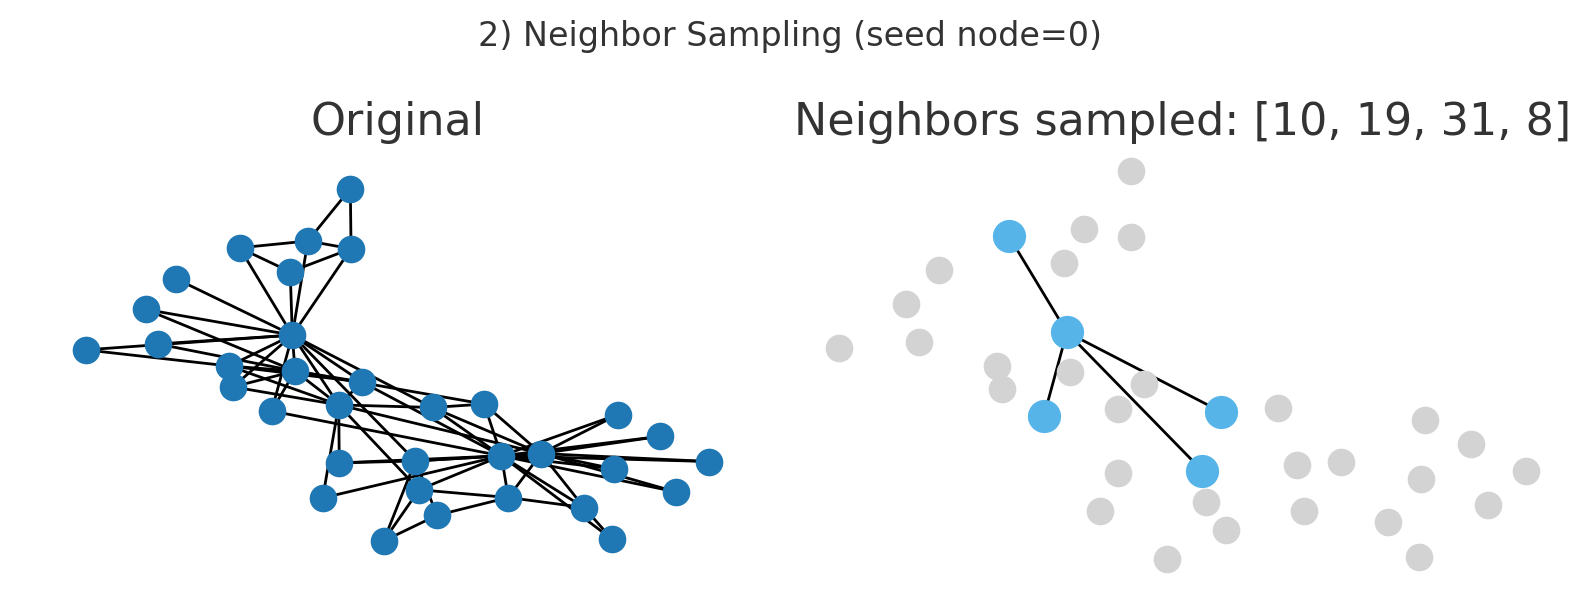

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 3️⃣ Layer-wise Sampling – نمونه‌گیری لایه‌ای

**چطور کار می‌کند؟ انتخاب تصادفی گره‌ها در هر لایهٔ GNN (مانند FastGCN).**  

🔹 نمونه‌گیری نه در سطح هر گره بلکه در سطح کل لایه انجام می‌شود. در هر لایه، مجموعه‌ای از گره‌ها براساس توزیع احتمال خاص انتخاب و پردازش می‌شوند (مثل FastGCN و LADIES).

**🔹 مثال:**  در FastGCN، در هر لایه مجموعه‌ای از گره‌ها براساس احتمال توزیع degree انتخاب می‌شوند تا پیام‌رسانی فقط بین آن‌ها صورت گیرد.

**✅ مزایا:**  
- •	مناسب برای پردازش توزیع‌شده (distributed computing)
- کاهش وابستگی‌های متقابل بین گره‌ها  
- مصرف حافظه و زمان کمتر

**🔹 مناسب برای:**  
- گراف‌های بسیار بزرگ  
- آموزش mini-batch با GPUهای محدود

**⚠️ محدودیت‌ها:**  
- ساختار همسایگی محلی ممکن است حفظ نشود  
- دقت مدل در وظایف محلی ممکن است کاهش یابد

</div>


In [68]:
# # 3) Layer-wise Sampling (BFS up to depth 2)
# def layerwise_sampling(G, start_node=0, num_layers=2):
#     layers = []
#     current = [start_node]
#     visited = set(current)
#     for _ in range(num_layers):
#         next_layer = []
#         for n in current:
#             for nbr in G.neighbors(n):
#                 if nbr not in visited:
#                     next_layer.append(nbr)
#                     visited.add(nbr)
#         layers.extend(next_layer)
#         current = next_layer
#     subG = G.subgraph([start_node]+layers).copy()
#     return subG, [start_node]+layers

# G_layer, layer_nodes = layerwise_sampling(G0, start_node=0, num_layers=2)
# plt.figure(figsize=(8,3))
# plt.suptitle("3) Layer-wise Sampling (BFS depth=2)")
# plt.subplot(1,2,1)
# nx.draw(G0, pos=pos, node_size=80, with_labels=False)
# plt.title("Original")
# plt.subplot(1,2,2)
# nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
# nx.draw(G_layer, pos=pos, node_color='C2', node_size=120, with_labels=False)
# plt.title("Sampled nodes: {}".format(len(layer_nodes)))
# plt.tight_layout()
# plt.show()


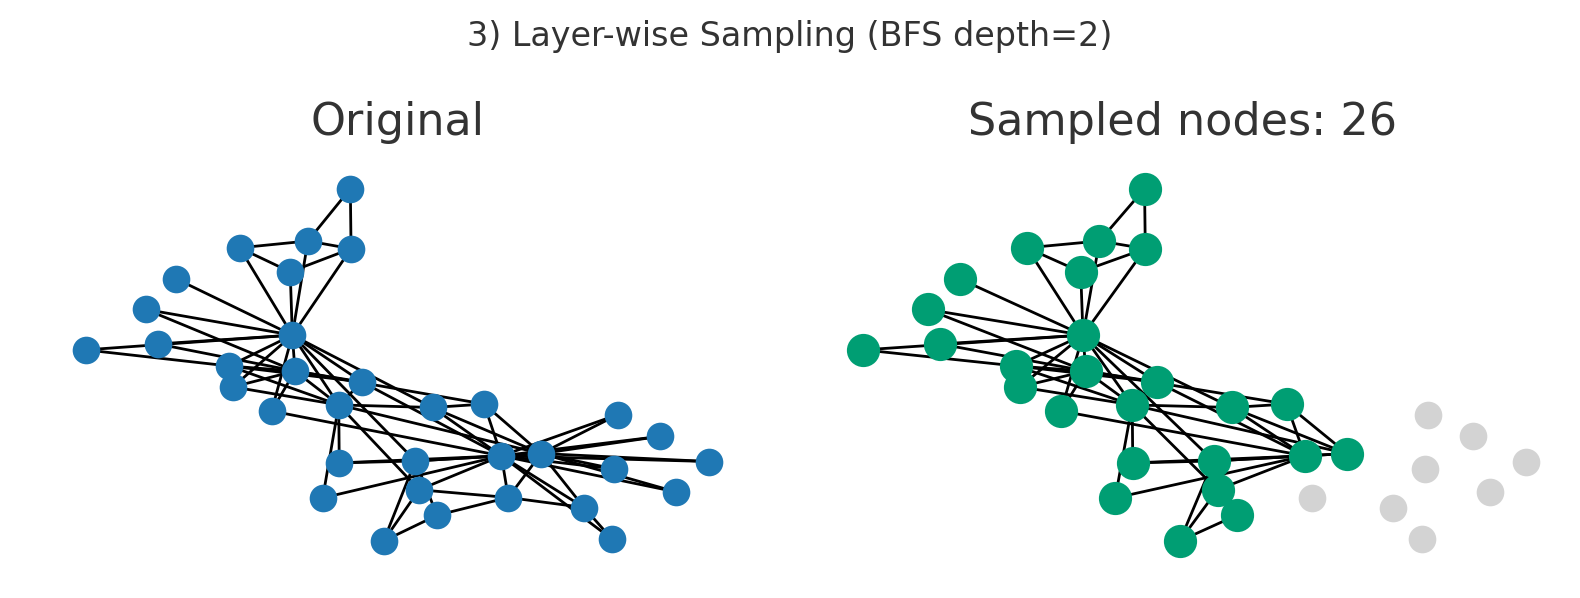

<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 4️⃣ Subgraph Sampling – نمونه‌گیری زیرگرافی

**چطور کار می‌کند؟ استخراج زیرگراف‌های کامل به‌صورت تصادفی.**  
🔹 به‌جای انتخاب گره‌های مجزا، زیرگراف‌های کامل به‌صورت تصادفی انتخاب می‌شوند.  
🔹 روش‌هایی مانند GraphSAINT از زیرگراف‌های random walk، node-based یا edge-based استفاده می‌کنند.

**🔹مثال:**  در GraphSAINT، زیرگراف‌هایی با حدود ۵۰۰ گره از گراف اصلی استخراج شده و هرکدام به‌صورت mini-batch پردازش می‌شوند.

**✅ مزایا:**  
- حفظ ارتباطات ساختاری واقعی  
- مناسب برای یادگیری کارآمد در گراف‌های بزرگ  
- پشتیبانی از mini-batch training

**⚠️ محدودیت‌ها:**  
- هم‌پوشانی زیاد بین زیرگراف‌ها ممکن است رخ دهد(redundancy)
- انتخاب زیرگراف مناسب نیاز به تنظیم دقیق پارامترها دارد

**🔹 مناسب برای:**  
- Graph-level learning  
- Self-supervised یا contrastive learning روی viewهای مختلف گراف

</div>


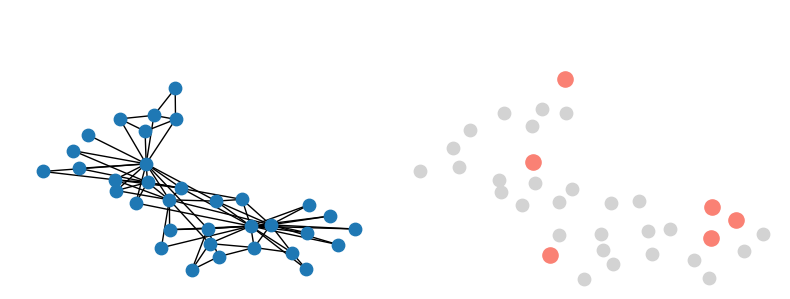

In [ ]:
# 4) Subgraph Sampling (already node-induced)
def subgraph_sampling(G, k=6):
    nodes = random.sample(list(G.nodes()), min(k, G.number_of_nodes()))
    subG = G.subgraph(nodes).copy()
    return subG, nodes

G_sub, sub_nodes = subgraph_sampling(G0, k=6)
plt.figure(figsize=(8,3))
plt.suptitle("4) Subgraph Sampling")
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_size=80, with_labels=False)
plt.title("Original")
plt.subplot(1,2,2)
nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
nx.draw(G_sub, pos=pos, node_color='C3', node_size=120, with_labels=False)
plt.title("Subgraph nodes: {}".format(sub_nodes))
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 5️⃣ Importance / Degree-based Sampling – نمونه‌گیری مبتنی بر اهمیت یا درجه

**چطور کار می‌کند؟ احتمال انتخاب بر اساس درجه یا مرکزیت گره‌ها.**  
🔹 در این روش، احتمال انتخاب هر گره بر اساس معیارهایی مانند درجه (Degree)، مرکزیت (Betweenness, Closeness) یا وزن‌های یادگرفته‌شده تعیین می‌شود.
گره‌های با اهمیت بیشتر، احتمال بالاتری برای انتخاب دارند.

**🔹 مثال:**  در یک گراف citation، مقالات پرارجاع (high-degree nodes) با احتمال بیشتری نمونه می‌شوند، چون نقش مهم‌تری در ساختار دانش دارند.

**✅ مزایا:**  
- تمرکز یادگیری روی بخش‌های کلیدی گراف  
- افزایش پایداری مدل در گراف‌های ناهمگن

**🔹 مناسب برای:**  
- گراف‌های با توزیع درجه‌ی سنگین (heavy-tailed) 
- تحلیل شبکه‌های اجتماعی یا citation networks

**⚠️ محدودیت‌ها:**  
- ممکن است مدل از گره‌های کم‌اهمیت (long tail) غافل بماند
- نیاز به محاسبهٔ معیارهای اضافی (که در گراف‌های بسیار بزرگ گران است).

</div>


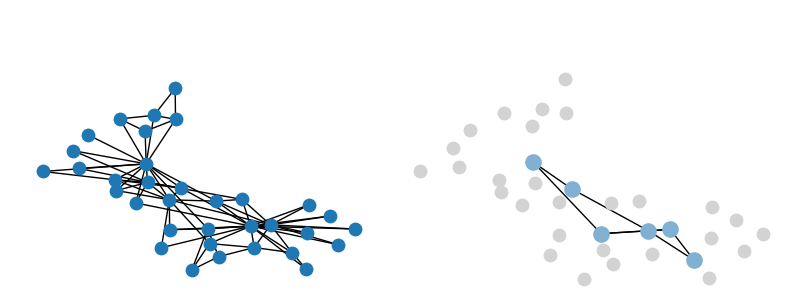

In [53]:
# 5) Importance Sampling (based on degree)
def importance_sampling(G, k=6):
    nodes = list(G.nodes())
    degrees = np.array([G.degree(n) for n in nodes], dtype=float)
    probs = degrees/degrees.sum()
    sampled = np.random.choice(nodes, size=min(k,len(nodes)), replace=False, p=probs)
    subG = G.subgraph(sampled).copy()
    return subG, sampled

G_imp, imp_nodes = importance_sampling(G0, k=6)
plt.figure(figsize=(8,3))
plt.suptitle("5) Importance Sampling (degree-based)")
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_size=80, with_labels=False)
plt.title("Original")
plt.subplot(1,2,2)
nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
nx.draw(G_imp, pos=pos, node_color='C4', node_size=120, with_labels=False)
plt.title("Sampled nodes: {}".format(imp_nodes))
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 6️⃣ Random Walk / Walk-based Sampling – نمونه‌گیری مبتنی بر گشت تصادفی

**چطور کار می‌کند؟ تولید مسیرهای تصادفی از گراف**  
🔹 در این روش، مسیرهایی از گراف با استفاده از گشت تصادفی (Random Walk) تولید می‌شوند.
این مسیرها درواقع توالی‌ای از گره‌ها هستند که همسایگی‌های محلی و ساختارهای دوربرد را ثبت می‌کنند.

🔹 روش‌های معروف: DeepWalk و node2vec

**🔹 مثال:**  در node2vec، با تنظیم پارامترهای p و q مسیرهایی تولید می‌شود که بین “exploration” و “exploitation” تعادل ایجاد کند.

**✅ مزایا:**  
- قابلیت استخراج همسایگی‌های بلندمدت (long-range dependencies)
- مناسب برای یادگیری embedding‌های غیربرچسب‌دار (unsupervised)

**🔹 مناسب برای:**  
- پیش‌پردازش برای یادگیری گراف embedding  
- وظایف link prediction و similarity search

**⚠️ محدودیت‌ها:**  
- زمان‌بر در گراف‌های بزرگ  
- نیاز به تنظیم دقیق پارامترها (bias, walk length, window size)

</div>


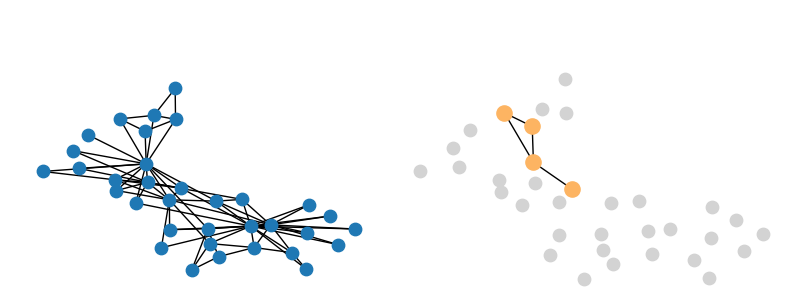

In [ ]:
# 6) Random Walk Sampling
def random_walk_sampling(G, start_node=0, walk_length=5):
    walk = [start_node]
    for _ in range(walk_length-1):
        nbrs = list(G.neighbors(walk[-1]))
        if nbrs:
            walk.append(random.choice(nbrs))
        else:
            break
    subG = G.subgraph(walk).copy()
    return subG, walk

G_rw, rw_nodes = random_walk_sampling(G0, start_node=0, walk_length=5)
plt.figure(figsize=(8,3))
plt.suptitle("6) Random Walk Sampling (length=5)")
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_size=80, with_labels=False)
plt.title("Original")
plt.subplot(1,2,2)
nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
nx.draw(G_rw, pos=pos, node_color='C5', node_size=120, with_labels=False)
plt.title("Walk nodes: {}".format(rw_nodes))
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 7️⃣ Edge / Negative Sampling – نمونه‌گیری یال‌ها

**چطور کار می‌کند؟**  
تمرکز بر انتخاب یال‌ها است. هم یال‌های واقعی و هم یال‌های منفی به صورت تصادفی انتخاب می‌شوند.

**🔹 مثال:**  در شبکه اجتماعی، یال‌های واقعی (افرادی که دوست هستند) و منفی (افرادی که هنوز دوست نیستند) با احتمال مساوی نمونه می‌شوند.

**✅ مزایا:**  
- بهبود کارایی یادگیری روابط  
- کنترل تعادل مثبت/منفی  
- مناسب برای وظایف مبتنی بر یال Edge-level

**⚠️ محدودیت‌ها:**  
- اگر یال‌های منفی به‌درستی انتخاب نشوند، مدل دچار bias می‌شود  
- در گراف‌های sparse، تشخیص یال‌های منفی دشوار است

**🔹 مناسب برای:**  
- Link Prediction، Recommendation، Graph Contrastive Learning

</div>


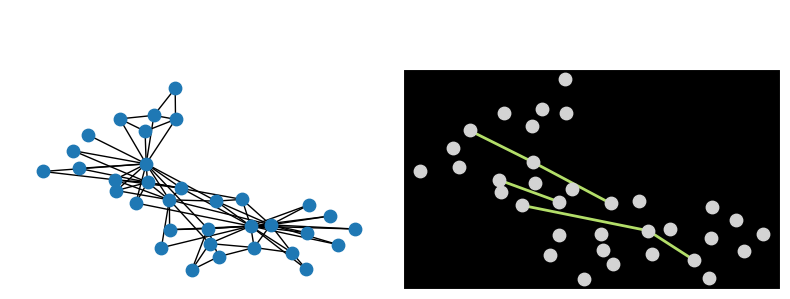

In [61]:
# 7) Edge / Negative Sampling
def edge_negative_sampling(G, num_pos=5, num_neg=5):
    pos_edges = random.sample(list(G.edges()), min(num_pos, G.number_of_edges()))
    neg_edges = random.sample(list(nx.non_edges(G)), min(num_neg, len(list(nx.non_edges(G)))))
    return pos_edges, neg_edges

pos_edges, neg_edges = edge_negative_sampling(G0)
plt.figure(figsize=(8,3))
plt.suptitle("7) Edge / Negative Sampling")
plt.subplot(1,2,1)
nx.draw(G0, pos=pos, node_size=80, with_labels=False)
plt.title("Original")
plt.subplot(1,2,2)
nx.draw_networkx_nodes(G0, pos=pos, node_color='lightgray', node_size=80)
nx.draw_networkx_edges(G0, pos=pos, edgelist=pos_edges, edge_color='C6', width=2)
plt.title("Positive sampled edges")
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-size:22px; margin-left:-30px;">

### 8️⃣ Temporal / Window Sampling – نمونه‌گیری زمانی

**چطور کار می‌کند؟**  
🔹 در گراف‌های پویا، پنجره‌های زمانی یا رویدادهای اخیر برای تحلیل یا آموزش انتخاب می‌شوند. نمونه‌گیری زمانی به معنی انتخاب پنجره‌های زمانی (time windows) یا رویدادهای اخیر برای تحلیل یا آموزش است.
این کار به مدل کمک می‌کند تا الگوهای زمانی را بهتر درک کند.

**🔹 مثال:**  در شبکهٔ تراکنش‌های مالی، برای شناسایی تقلب، می‌توان تنها تراکنش‌های ۳۰ روز اخیر هر کاربر را به‌عنوان زیرگراف زمانی انتخاب کرد.

**✅ مزایا:**  
- مناسب برای گراف‌های پویای بزرگ
- تمرکز مدل بر روی رفتارهای اخیر و به‌روز.
- قابلیت پیاده‌سازی در زمان واقعی (real-time)

**⚠️ محدودیت‌ها:**  
- اگر پنجره‌ی زمانی خیلی کوچک باشد، مدل دچار کمبود داده می‌شود
- از دست دادن اطلاعات تاریخی بلندمدت

**🔹 مناسب برای:**  
- Dynamic Graph Learning  
- Stream-based models، anomaly detection، fraud detection

</div>


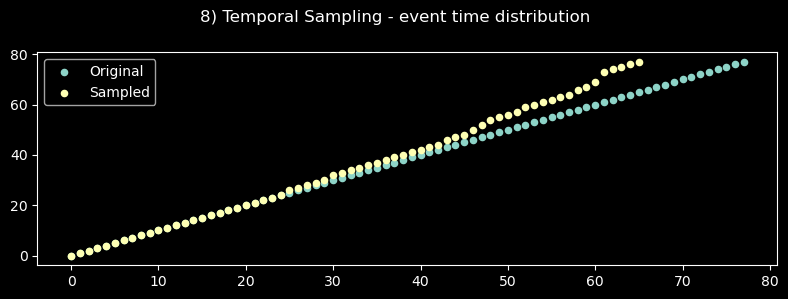

In [ ]:
# # 8) Temporal Sampling (simulated timestamps)
# def temporal_sampling(G, drop_prob=0.2):
#     events = [(u,v,t) for t,(u,v) in enumerate(G.edges())]
#     sampled = [e for e in events if np.random.rand()>=drop_prob]
#     return sampled

# temp_events = temporal_sampling(G0, drop_prob=0.2)
# plt.figure(figsize=(8,3))
# plt.suptitle("8) Temporal Sampling - event time distribution")
# times_orig = list(range(len(G0.edges())))
# times_sampled = [e[2] for e in temp_events]
# plt.scatter(times_orig, times_orig, s=20, label='Original')
# plt.scatter(range(len(times_sampled)), times_sampled, s=20, label='Sampled')
# plt.legend()
# plt.tight_layout()
# plt.show()


<div align="center" dir="rtl" style="font-size:22px; line-height:1.8; text-align:center; margin-left:-30px;">

### خلاصه کلی روش های Augmentation


<div dir="rtl" style="font-size:22px; display:flex; justify-content:center; line-height:1.8;">

<table>
<thead>
<tr>
<th>🔹 روش</th>
<th>⚙️ نوع نمونه‌گیری</th>
<th>🎯 مناسب برای</th>
<th>⚠️ چالش اصلی</th>
</tr>
</thead>
<tbody>
<tr>
<td>🎲 Uniform Node</td>
<td>تصادفی ساده</td>
<td>برآورد آماری</td>
<td>از دست دادن ساختار</td>
</tr>
<tr>
<td>🧭 Neighbor</td>
<td>همسایگی محلی</td>
<td>Node Classification</td>
<td>حذف همسایه‌های مهم</td>
</tr>
<tr>
<td>🧩 Layer-wise</td>
<td>لایه‌ای</td>
<td>آموزش توزیع‌شده</td>
<td>از بین رفتن وابستگی محلی</td>
</tr>
<tr>
<td>🕸 Subgraph</td>
<td>زیرگرافی</td>
<td>Mini-batch در گراف‌های بزرگ</td>
<td>هم‌پوشانی زیاد</td>
</tr>
<tr>
<td>💎 Importance</td>
<td>وزنی / درجه‌ای</td>
<td>تمرکز بر گره‌های مهم</td>
<td>نادیده‌گرفتن long-tail</td>
</tr>
<tr>
<td>🚶‍♂️ Random Walk</td>
<td>مسیرمحور</td>
<td>Embedding، Similarity</td>
<td>هزینهٔ زیاد و حساسیت بالا</td>
</tr>
<tr>
<td>🔗 Edge / Negative</td>
<td>یال‌محور</td>
<td>Link Prediction</td>
<td>انتخاب نمونه منفی مناسب</td>
</tr>
<tr>
<td>⏳ Temporal</td>
<td>زمانی</td>
<td>Graph‌های پویا</td>
<td>از دست دادن تاریخ بلندمدت</td>
</tr>
</tbody>
</table>

</div>



<div dir="rtl" style="font-size:22px; text-align:center;">

---

## 💯 روش‌های Augmentation پیشرفته‌تر

| نوع | ایده کلی | کاربرد یا نکته آموزشی |
|-----|-----------|--------------------|
| 🧠 Semantic Augmentation | تغییر گره‌ها/یال‌هایی که از نظر معنایی مشابه‌اند (مثلاً دو گره هم‌نقش) | برای گراف‌های اجتماعی یا دانش، حفظ معنی در augment |
| 🔀 Role-based Augmentation | گره‌هایی با نقش مشابه در ساختار (hub, bridge, leaf) جایگزین یا swap شوند | تمرین نقش‌های ساختاری و تاثیرشان در embedding |
| ⚡ Edge Addition via Similarity | اضافه‌کردن یال بین گره‌هایی که embedding یا ویژگی‌شان مشابه است | نشان دادن تأثیر تقویت connectivity بر دقت مدل |
| 🌪 Graph Diffusion Augmentation (GDC / PPR diffusion) | بازنویسی ساختار گراف با انتشار (diffusion) — مثل personalized PageRank | درک اثر smoothing یا diffusion بر propagation اطلاعات |
| 🎯 Adaptive Edge Dropping (information-aware) | حذف یال‌ها بر اساس میزان اطلاعاتی که منتقل می‌کنند (entropy, attention weights) | تمرین “مهم‌ترین یال‌ها” و regularization هوشمند |
| 🪄 Subgraph Isomorphism Augmentation | شناسایی و کپی‌کردن patternهای تکراری (motifs, triangles) | برای تحلیل motif-based GNNها |
| 🧬 GraphMix (Mixup for Graphs) | ترکیب embedding دو گراف (feature-level mixup) | برای graph-level classification و regularization |
| 🌐 View Augmentation via Graph Partitioning | تقسیم گراف به چند بخش (views) و استفاده در contrastive learning | برای تمرین multi-view representation learning |
| 🧩 Graph Editing Augmentation | اعمال عملگرهای تصادفی ولی محدود (add/remove edge/node) در چند مرحله | آموزش مدل برای پایداری نسبت به تغییرات ساختار |
| ⏳ Temporal Perturbation | در گراف‌های زمانی، جابجایی جزئی timestamps یا reorder رویدادها | برای بررسی حساسیت مدل به ترتیب زمانی |
| 🧱 Spectral Augmentation | دستکاری eigenvalues/eigenvectors لاپلاسین برای تولید گراف‌های مشابه در طیف فرکانسی | تمرین مفاهیم طیفی و پیوند بین سیگنال و ساختار |
| 🔄 Topology Morphing | تغییر کوچک در ساختار کلی (مثلاً حذف حلقه‌ها، اضافه‌کردن bridge) | نشان دادن تأثیر topology روی propagation |

</div>


<div dir="rtl" style="font-size:22px; text-align:center;">

## 💥 روش‌های Sampling پیشرفته‌تر

| نوع | ایده کلی | کاربرد یا نکته آموزشی |
|-----|-----------|--------------------|
| 🔁 Random Walk with Restart (RWR) Sampling | شروع از گره هدف، با احتمال مشخص به خودش برمی‌گردد | درک diffusion محلی و یادگیری context نزدیک |
| 🎯 Importance-aware Neighbor Sampling | وزن‌دهی به همسایه‌ها بر اساس attention یا centrality | نشان دادن sampling تطبیقی |
| 🔀 Hierarchical / Coarsened Sampling | ساخت گراف‌های فشرده (coarse) و نمونه‌گیری از آن‌ها | آموزش چندمقیاسی (multi-scale learning) |
| ⚡ Cluster-based Sampling | گراف را خوشه‌بندی و سپس از خوشه‌ها نمونه می‌گیریم | مناسب برای large-scale training (مثل Cluster-GCN) |
| 🕸 Snowball / Expansion Sampling | شروع از seed node و افزودن همسایه‌ها به صورت لایه‌ای (مثل BFS) | مفید برای local subgraph extraction |
| 🧭 Reinforcement Learning-based Sampling | عامل RL یاد می‌گیرد کدام گره‌ها/یال‌ها را برای یادگیری انتخاب کند | ایدهٔ پیشرفته برای adaptive sampling |
| 🧱 Structure-preserving Sampling | هدف حفظ ویژگی‌های آماری کل گراف (degree distribution, clustering coefficient) | برای بررسی bias در sampling |
| 🧩 Negative Graph Sampling (for contrastive / link prediction) | ساخت گراف “منفی” با حذف یا جابجایی یال‌ها برای یادگیری contrastive | درک مفهوم positive/negative views |
| ⏱ Temporal / Event-based Sampling | انتخاب زیرمجموعهٔ تعاملات اخیر بر اساس زمان | برای گراف‌های زمانی و memory-based GNNها |
| 🔮 Meta-Sampling / Active Sampling | یادگیری توزیع بهینه برای نمونه‌گیری بر اساس loss قبلی | موضوع پژوهشی جدید در meta-learning for GNNs |

</div>


<div dir="rtl" style="font-size:32px; text-align:center;">

# The END ✔
## Armin KHoojavi 👨‍💻

</div>